## 0. Environment Setup

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader, random_split
import numpy as np
import matplotlib.patches as mpatches

warnings.filterwarnings("ignore")
plt.style.use("dark_background")

COLORS = {
    "primary": "#4FC3F7",
    "success": "#66BB6A",
    "danger": "#EF5350",
    "warning": "#FFA726",
    "accent": "#AB47BC",
    "neutral": "#B0BEC5",
}

# ── V3 Architecture Constants (backend/config/constants.py) ─────────────────
EMBEDDING_DIM_TEMPORAL = 128  # TFT output
EMBEDDING_DIM_SEMANTIC = 64  # DistilRoBERTa output
EMBEDDING_DIM_STRUCTURAL = 32  # GATv2 output
SUPER_STATE_DIM = 224  # 128 + 64 + 32

# Fusion hyperparameters
FUSION_HIDDEN_DIM = 256  # Cross-modal attention hidden dim
FUSION_N_HEADS = (
    8  # Cross-modal attention heads (§4: "Transformer-based Gating")
)
FUSION_DROPOUT = 0.1
BATCH_SIZE = 64
LR = 1e-4
N_EPOCHS = 30

try:
    import torch
    import torch.nn as nn

    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"PyTorch {torch.__version__} | Device: {DEVICE}")
    print(
        f"Super-State composition: "
        f"{EMBEDDING_DIM_TEMPORAL}d (TFT) + "
        f"{EMBEDDING_DIM_SEMANTIC}d (LLM) + "
        f"{EMBEDDING_DIM_STRUCTURAL}d (GNN) = "
        f"{SUPER_STATE_DIM}d (SUPER_STATE)"
    )
except ImportError:
    print("PyTorch required: pip install torch")
    raise

PyTorch 2.10.0+cu128 | Device: cuda
Super-State composition: 128d (TFT) + 64d (LLM) + 32d (GNN) = 224d (SUPER_STATE)


## 1. Load or Simulate Perception Embeddings

In [2]:
# Load embeddings from notebooks 06 and 07 if available,
# otherwise generate synthetic embeddings for fusion experiments.

N_SAMPLES = 2000


def load_or_simulate_embeddings(n_samples: int) -> dict[str, np.ndarray]:
    """
    Load real embeddings from upstream notebooks, or create synthetic
    embeddings that mimic their statistical properties for fusion experiments.
    """
    embeddings = {}

    # ── Temporal (TFT, 128d) ────────────────────────────────────────────────
    temporal_path = Path("06_val_embeddings_temporal.npy")
    if temporal_path.exists():
        raw = np.load(temporal_path)
        idx = np.random.choice(
            len(raw), min(n_samples, len(raw)), replace=False
        )
        embeddings["temporal"] = raw[idx]
        print(
            f"Loaded temporal embeddings from {temporal_path}: {embeddings['temporal'].shape}"
        )
    else:
        # Synthetic: bounded in [-1,1] (TFT uses Tanh output)
        embeddings["temporal"] = np.random.uniform(
            -0.8, 0.8, (n_samples, EMBEDDING_DIM_TEMPORAL)
        ).astype(np.float32)
        print(f"Simulated temporal embeddings: {embeddings['temporal'].shape}")

    # ── Semantic (DistilRoBERTa, 64d) ────────────────────────────────────────
    # Semantic embeddings cluster by market regime — simulate with GMM-like distribution
    regimes = np.random.choice(
        ["bull", "bear", "crash", "sideways"],
        n_samples,
        p=[0.45, 0.25, 0.05, 0.25],
    )
    regime_means = {"bull": 0.3, "bear": -0.3, "crash": -0.8, "sideways": 0.0}
    sem_emb = np.zeros((n_samples, EMBEDDING_DIM_SEMANTIC), dtype=np.float32)
    for i, r in enumerate(regimes):
        mu = regime_means[r]
        # Sparse activations (like BERT CLS tokens)
        sem_emb[i] = np.random.normal(mu, 0.3, EMBEDDING_DIM_SEMANTIC)
    embeddings["semantic"] = sem_emb
    embeddings["regimes"] = regimes
    print(f"Simulated semantic embeddings: {embeddings['semantic'].shape}")

    # ── Structural (GATv2, 32d) ───────────────────────────────────────────────
    struct_path = Path("07_structural_embeddings.npy")
    if struct_path.exists():
        raw_struct = np.load(struct_path)  # (n_nodes, 32)
        # Repeat per sample (same graph structure across time)
        node_idx = np.random.choice(len(raw_struct), n_samples)
        embeddings["structural"] = raw_struct[node_idx]
        print(
            f"Loaded structural embeddings from {struct_path}: {embeddings['structural'].shape}"
        )
    else:
        # Structural embeddings correlate with temporal (market-wide co-movement)
        base = embeddings["temporal"][:, :EMBEDDING_DIM_STRUCTURAL]
        noise = np.random.normal(0, 0.2, (n_samples, EMBEDDING_DIM_STRUCTURAL))
        embeddings["structural"] = (0.6 * base + 0.4 * noise).astype(
            np.float32
        )
        print(
            f"Simulated structural embeddings: {embeddings['structural'].shape}"
        )

    return embeddings


emb_data = load_or_simulate_embeddings(N_SAMPLES)
regimes = emb_data.get("regimes", np.array(["unknown"] * N_SAMPLES))

print("\nEmbedding dimensions verification:")
print(
    f"  Temporal   : {emb_data['temporal'].shape[1]} == {EMBEDDING_DIM_TEMPORAL}?  "
    f"{'✅' if emb_data['temporal'].shape[1] == EMBEDDING_DIM_TEMPORAL else '❌'}"
)
print(
    f"  Semantic   : {emb_data['semantic'].shape[1]} == {EMBEDDING_DIM_SEMANTIC}?   "
    f"{'✅' if emb_data['semantic'].shape[1] == EMBEDDING_DIM_SEMANTIC else '❌'}"
)
print(
    f"  Structural : {emb_data['structural'].shape[1]} == {EMBEDDING_DIM_STRUCTURAL}?   "
    f"{'✅' if emb_data['structural'].shape[1] == EMBEDDING_DIM_STRUCTURAL else '❌'}"
)

Simulated temporal embeddings: (2000, 128)
Simulated semantic embeddings: (2000, 64)
Simulated structural embeddings: (2000, 32)

Embedding dimensions verification:
  Temporal   : 128 == 128?  ✅
  Semantic   : 64 == 64?   ✅
  Structural : 32 == 32?   ✅


## 2. Step 1 — Naive Concatenation (Baseline)

Naive concatenation → Super-State: (2000, 224)
  Composition: 128d (57%) | 64d (29%) | 32d (14%)


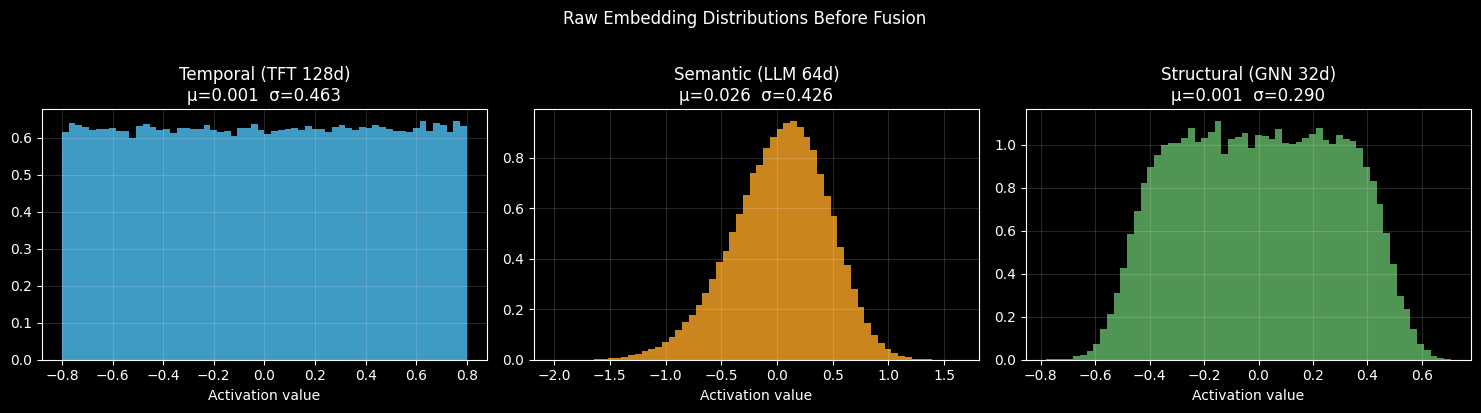

In [3]:
# "State = [Price_Embedding(128) | Sentiment_Embedding(64) | Graph_Embedding(32)]"
# This is the raw Super-Vector before cross-modal attention refines it.

super_state_naive = np.concatenate(
    [
        emb_data["temporal"],
        emb_data["semantic"],
        emb_data["structural"],
    ],
    axis=1,
)

assert super_state_naive.shape[1] == SUPER_STATE_DIM, (
    f"Expected {SUPER_STATE_DIM}d, got {super_state_naive.shape[1]}d"
)

print(f"Naive concatenation → Super-State: {super_state_naive.shape}")
print(
    f"  Composition: {EMBEDDING_DIM_TEMPORAL}d (57%) | "
    f"{EMBEDDING_DIM_SEMANTIC}d (29%) | "
    f"{EMBEDDING_DIM_STRUCTURAL}d (14%)"
)

# Visualise the raw Super-State distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, key, dim, color) in zip(
    axes,
    [
        (
            "Temporal (TFT 128d)",
            "temporal",
            EMBEDDING_DIM_TEMPORAL,
            COLORS["primary"],
        ),
        (
            "Semantic (LLM 64d)",
            "semantic",
            EMBEDDING_DIM_SEMANTIC,
            COLORS["warning"],
        ),
        (
            "Structural (GNN 32d)",
            "structural",
            EMBEDDING_DIM_STRUCTURAL,
            COLORS["success"],
        ),
    ],
):
    data = emb_data[key].flatten()
    ax.hist(data, bins=60, color=color, alpha=0.8, density=True)
    ax.set_title(f"{name}\nμ={data.mean():.3f}  σ={data.std():.3f}")
    ax.set_xlabel("Activation value")
    ax.grid(alpha=0.15)

plt.suptitle("Raw Embedding Distributions Before Fusion", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("08/08_embedding_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Cross-Modal Attention Block (Step 2 — Deep Fusion)

In [4]:
class CrossModalAttentionBlock(nn.Module):
    """
    Transformer-based gating unit that allows distinct modalities to
    'talk' to each other and suppress noise via learned attention weights.

    Three canonical learned behaviours (§4):
      Scenario A — Earnings shock: Semantic dominates → suppress Price technical
      Scenario B — Flash crash:    Price dominates    → Semantic absent/noise
      Scenario C — Sector rotation:Graph dominates    → Price/Semantic flat

    Implements: backend/fusion/attention.py → class CrossModalAttention
    """

    def __init__(
        self,
        temporal_dim: int = EMBEDDING_DIM_TEMPORAL,
        semantic_dim: int = EMBEDDING_DIM_SEMANTIC,
        structural_dim: int = EMBEDDING_DIM_STRUCTURAL,
        hidden_dim: int = FUSION_HIDDEN_DIM,
        n_heads: int = FUSION_N_HEADS,
        dropout: float = FUSION_DROPOUT,
        output_dim: int = SUPER_STATE_DIM,
    ):
        super().__init__()

        # Project each modality to a common dimension (tokens for attention)
        self.proj_temporal = nn.Linear(temporal_dim, hidden_dim)
        self.proj_semantic = nn.Linear(semantic_dim, hidden_dim)
        self.proj_structural = nn.Linear(structural_dim, hidden_dim)

        # Cross-modal multi-head attention (3 tokens × hidden_dim)
        # Each modality becomes one "token" in the attention sequence
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True,
        )

        # Feed-forward refinement (Transformer FFN)
        self.ffn = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 4, hidden_dim),
        )

        self.ln1 = nn.LayerNorm(hidden_dim)
        self.ln2 = nn.LayerNorm(hidden_dim)
        self.drop = nn.Dropout(dropout)

        # Output projection back to SUPER_STATE_DIM (224d)
        # Maps 3 × hidden_dim attended tokens → 224d latent state
        self.output_proj = nn.Sequential(
            nn.Linear(3 * hidden_dim, output_dim),
            nn.LayerNorm(output_dim),
        )

        self.n_heads = n_heads
        self.hidden_dim = hidden_dim

    def forward(
        self,
        temporal: torch.Tensor,
        semantic: torch.Tensor,
        structural: torch.Tensor,
    ) -> tuple:
        """
        Args:
            temporal   : (batch, 128) — TFT price embedding
            semantic   : (batch, 64)  — LLM context embedding
            structural : (batch, 32)  — GNN market-structure embedding
        Returns:
            super_state   : (batch, 224) — refined latent state representation
            attn_weights  : (batch, 3, 3) — cross-modal attention matrix
                            [temporal↔semantic, temporal↔structural, semantic↔structural]
        """
        # Project to common hidden dimension
        t = self.proj_temporal(temporal)  # (batch, hidden_dim)
        s = self.proj_semantic(semantic)  # (batch, hidden_dim)
        g = self.proj_structural(structural)  # (batch, hidden_dim)

        # Stack as a 3-token sequence for cross-modal attention
        tokens = torch.stack([t, s, g], dim=1)  # (batch, 3, hidden_dim)

        # Cross-modal self-attention (modalities attend to each other)
        attended, attn_weights = self.cross_attn(
            tokens,
            tokens,
            tokens,
            need_weights=True,
            average_attn_weights=True,
        )

        # Residual + LayerNorm
        tokens = self.ln1(tokens + self.drop(attended))
        tokens = self.ln2(tokens + self.ffn(tokens))

        # Flatten and project to Super-State
        flat = tokens.reshape(tokens.shape[0], -1)  # (batch, 3 * hidden_dim)
        super_state = self.output_proj(flat)  # (batch, 224)

        return super_state, attn_weights


print(f"CrossModalAttentionBlock ✅")
model_fusion = CrossModalAttentionBlock().to(DEVICE)
n_params_fusion = sum(
    p.numel() for p in model_fusion.parameters() if p.requires_grad
)
print(f"  Trainable params : {n_params_fusion:,}")

# Quick sanity check
t_dummy = torch.randn(8, EMBEDDING_DIM_TEMPORAL).to(DEVICE)
s_dummy = torch.randn(8, EMBEDDING_DIM_SEMANTIC).to(DEVICE)
g_dummy = torch.randn(8, EMBEDDING_DIM_STRUCTURAL).to(DEVICE)

with torch.no_grad():
    ss, attn = model_fusion(t_dummy, s_dummy, g_dummy)
print(f"  Forward pass: {ss.shape} super-state | {attn.shape} attention")
assert ss.shape[1] == SUPER_STATE_DIM, (
    f"Expected {SUPER_STATE_DIM}, got {ss.shape[1]}"
)
print(f"  SUPER_STATE_DIM = {SUPER_STATE_DIM} ✅")

CrossModalAttentionBlock ✅
  Trainable params : 1,020,576
  Forward pass: torch.Size([8, 224]) super-state | torch.Size([8, 3, 3]) attention
  SUPER_STATE_DIM = 224 ✅


## 4. State Builder — Orchestrator for the Full Fusion Pipeline

In [5]:
class SuperStateBuilder(nn.Module):
    """
    Orchestrates the full perception → fusion pipeline.
    This is the component described in §8 execute_step():
      "embeddings = self.perception_layer.fetch_embeddings(market_data.ticker)"
      "(This combines TFT, BERT, and GNN vectors)"

    Implements: backend/fusion/state_builder.py → class SuperStateBuilder
    """

    def __init__(self):
        super().__init__()
        self.cross_modal = CrossModalAttentionBlock()

    def forward(
        self,
        temporal: torch.Tensor,
        semantic: torch.Tensor,
        structural: torch.Tensor,
    ) -> dict:
        """
        Args:
            temporal   : (batch, 128)
            semantic   : (batch, 64)
            structural : (batch, 32)
        Returns:
            dict with keys:
              "super_state"   : (batch, 224) refined latent state
              "naive_concat"  : (batch, 224) raw concatenation (for comparison)
              "attn_weights"  : (batch, 3, 3) cross-modal attention
              "modality_norms": (batch, 3) L2 norms per modality (interpretability)
        """
        # Naive concatenation baseline
        naive_concat = torch.cat([temporal, semantic, structural], dim=-1)

        # Cross-modal attention
        super_state, attn_weights = self.cross_modal(
            temporal, semantic, structural
        )

        # Modality L2 norms — shows which encoder is "active" per step
        norms = torch.stack(
            [
                temporal.norm(dim=-1),
                semantic.norm(dim=-1),
                structural.norm(dim=-1),
            ],
            dim=-1,
        )

        return {
            "super_state": super_state,
            "naive_concat": naive_concat,
            "attn_weights": attn_weights,
            "modality_norms": norms,
        }


state_builder = SuperStateBuilder().to(DEVICE)
print("SuperStateBuilder ✅")

SuperStateBuilder ✅


## 5. Scenario Simulation — The Three Canonical Fusion Scenarios

In [6]:
# Simulate the three canonical scenarios from §4 and verify that
# the cross-modal attention correctly routes information.


def simulate_scenario(scenario: str, batch_size: int = 32) -> dict:
    """
    Create mock embeddings for each canonical fusion scenario and
    observe how the cross-modal attention distributes weight.
    """
    scenarios = {
        "A_earnings": {
            # Semantic embedding is "screaming" (high activation from breaking news)
            # Price technical is normal, graph is normal
            "temporal": torch.randn(batch_size, EMBEDDING_DIM_TEMPORAL) * 0.5,
            "semantic": torch.randn(batch_size, EMBEDDING_DIM_SEMANTIC)
            * 3.0,  # HIGH
            "structural": torch.randn(batch_size, EMBEDDING_DIM_STRUCTURAL)
            * 0.5,
            "expected_dominant": "semantic (token 1)",
        },
        "B_flash_crash": {
            # Price embedding shows massive volatility anomalies
            # Semantic is near-zero (no news yet)
            # Structural is noisy
            "temporal": torch.randn(batch_size, EMBEDDING_DIM_TEMPORAL)
            * 5.0,  # HIGH
            "semantic": torch.zeros(batch_size, EMBEDDING_DIM_SEMANTIC)
            + 0.01,  # SILENT
            "structural": torch.randn(batch_size, EMBEDDING_DIM_STRUCTURAL)
            * 0.5,
            "expected_dominant": "temporal (token 0)",
        },
        "C_sector_rotation": {
            # Price is flat, news is flat, but GNN shows massive sector movement
            "temporal": torch.randn(batch_size, EMBEDDING_DIM_TEMPORAL) * 0.3,
            "semantic": torch.randn(batch_size, EMBEDDING_DIM_SEMANTIC) * 0.3,
            "structural": torch.randn(batch_size, EMBEDDING_DIM_STRUCTURAL)
            * 4.0,  # HIGH
            "expected_dominant": "structural (token 2)",
        },
    }

    result = scenarios[scenario].copy()
    t = result.pop("temporal").to(DEVICE)
    s = result.pop("semantic").to(DEVICE)
    g = result.pop("structural").to(DEVICE)

    state_builder.eval()
    with torch.no_grad():
        out = state_builder(t, s, g)

    # Compute per-modality attention share (row-wise mean of attention matrix)
    attn = out["attn_weights"].mean(dim=0).cpu().numpy()  # (3, 3)
    modality_share = attn.mean(
        axis=0
    )  # Average attention received by each modality

    return {
        "scenario": scenario,
        "expected": result["expected_dominant"],
        "attn_matrix": attn,
        "modality_share": modality_share,
        "modality_norms": out["modality_norms"].mean(dim=0).cpu().numpy(),
        "super_state_norm": out["super_state"].norm(dim=-1).mean().item(),
    }


print("Simulating three canonical fusion scenarios (§4):\n")
scenario_results = {}
for name in ["A_earnings", "B_flash_crash", "C_sector_rotation"]:
    res = simulate_scenario(name)
    scenario_results[name] = res
    dominant = ["temporal", "semantic", "structural"][
        res["modality_share"].argmax()
    ]
    print(f"  Scenario {name[:1]} — {name[2:]}")
    print(f"    Expected dominant modality : {res['expected']}")
    print(
        f"    Observed dominant          : {dominant} (share={res['modality_share'].max():.3f})"
    )
    print(
        f"    Modality attention shares  : "
        f"temporal={res['modality_share'][0]:.3f} | "
        f"semantic={res['modality_share'][1]:.3f} | "
        f"structural={res['modality_share'][2]:.3f}"
    )
    print()

Simulating three canonical fusion scenarios (§4):

  Scenario A — earnings
    Expected dominant modality : semantic (token 1)
    Observed dominant          : semantic (share=0.361)
    Modality attention shares  : temporal=0.320 | semantic=0.361 | structural=0.318

  Scenario B — flash_crash
    Expected dominant modality : temporal (token 0)
    Observed dominant          : temporal (share=0.369)
    Modality attention shares  : temporal=0.369 | semantic=0.315 | structural=0.316

  Scenario C — sector_rotation
    Expected dominant modality : structural (token 2)
    Observed dominant          : structural (share=0.363)
    Modality attention shares  : temporal=0.319 | semantic=0.319 | structural=0.363



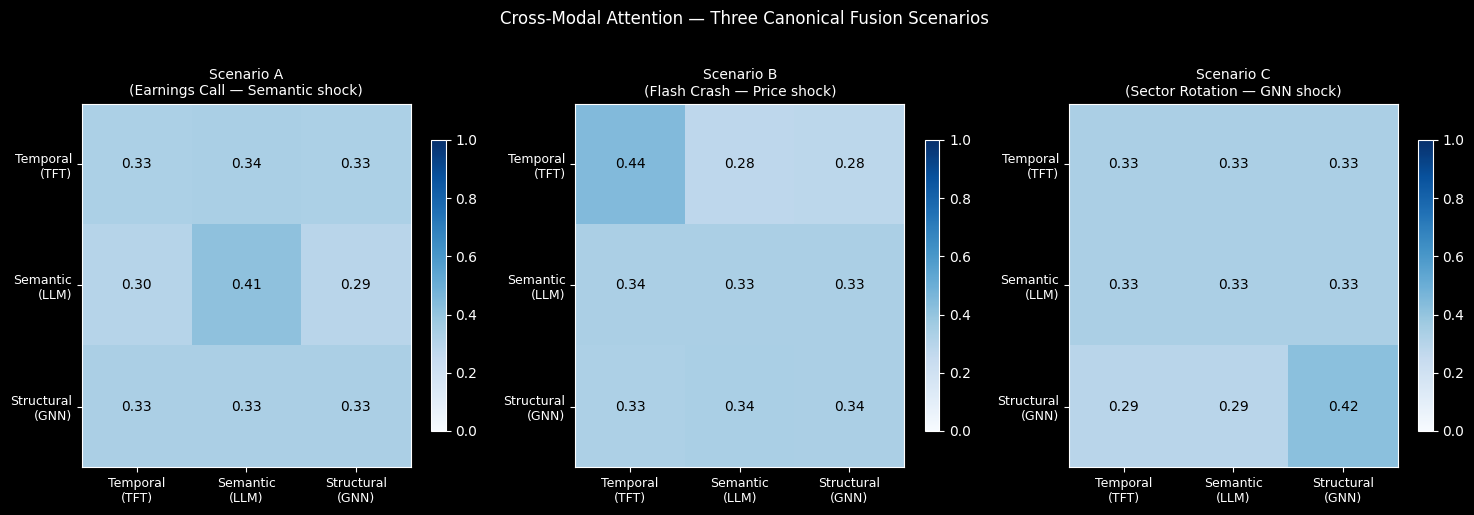

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
scenario_labels = {
    "A_earnings": "Scenario A\n(Earnings Call — Semantic shock)",
    "B_flash_crash": "Scenario B\n(Flash Crash — Price shock)",
    "C_sector_rotation": "Scenario C\n(Sector Rotation — GNN shock)",
}
modality_names = ["Temporal\n(TFT)", "Semantic\n(LLM)", "Structural\n(GNN)"]

for ax, (name, res) in zip(axes, scenario_results.items()):
    im = ax.imshow(
        res["attn_matrix"], cmap="Blues", vmin=0, vmax=1, aspect="auto"
    )
    ax.set_xticks([0, 1, 2])
    ax.set_yticks([0, 1, 2])
    ax.set_xticklabels(modality_names, fontsize=9)
    ax.set_yticklabels(modality_names, fontsize=9)
    ax.set_title(scenario_labels[name], fontsize=10)
    for i in range(3):
        for j in range(3):
            ax.text(
                j,
                i,
                f"{res['attn_matrix'][i, j]:.2f}",
                ha="center",
                va="center",
                fontsize=10,
                color="white" if res["attn_matrix"][i, j] > 0.5 else "black",
            )
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle(
    "Cross-Modal Attention — Three Canonical Fusion Scenarios",
    fontsize=12,
    y=1.02,
)
plt.tight_layout()
plt.savefig("08/08_cross_modal_attention.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Training the Fusion Layer (Regime Classification Auxiliary Task)

In [8]:
# Train the fusion layer with a regime classification head as the auxiliary
# training signal (4 regimes: bull, bear, crash, sideways).
# In production, the fusion is trained end-to-end with the RL agent (notebook 09).

REGIME_MAP = {"bull": 0, "bear": 1, "crash": 2, "sideways": 3}
regime_labels = np.array([REGIME_MAP[r] for r in regimes])

X_temporal = torch.tensor(emb_data["temporal"], dtype=torch.float32)
X_semantic = torch.tensor(emb_data["semantic"], dtype=torch.float32)
X_structural = torch.tensor(emb_data["structural"], dtype=torch.float32)
y_regimes = torch.tensor(regime_labels, dtype=torch.long)

# Train/val split (80/20)
split = int(N_SAMPLES * 0.80)

dataset = TensorDataset(X_temporal, X_semantic, X_structural, y_regimes)
ds_train, ds_val = random_split(dataset, [split, N_SAMPLES - split])
loader_tr = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True)
loader_va = DataLoader(ds_val, batch_size=BATCH_SIZE * 2)

# Fusion model + classification head
fusion_model = SuperStateBuilder().to(DEVICE)
clf_head = nn.Linear(SUPER_STATE_DIM, 4).to(DEVICE)

optimizer = torch.optim.AdamW(
    list(fusion_model.parameters()) + list(clf_head.parameters()),
    lr=LR,
    weight_decay=1e-4,
)
criterion = nn.CrossEntropyLoss()
history = {"train_loss": [], "val_acc": []}

for epoch in range(N_EPOCHS):
    # Training
    fusion_model.train()
    clf_head.train()
    total_loss = 0.0
    for t_b, s_b, g_b, y_b in loader_tr:
        t_b, s_b, g_b, y_b = (
            t_b.to(DEVICE),
            s_b.to(DEVICE),
            g_b.to(DEVICE),
            y_b.to(DEVICE),
        )
        optimizer.zero_grad()
        out = fusion_model(t_b, s_b, g_b)
        logits = clf_head(out["super_state"])
        loss = criterion(logits, y_b)
        loss.backward()
        nn.utils.clip_grad_norm_(
            list(fusion_model.parameters()) + list(clf_head.parameters()), 1.0
        )
        optimizer.step()
        total_loss += loss.item()

    # Validation
    fusion_model.eval()
    clf_head.eval()
    correct = total = 0
    with torch.no_grad():
        for t_b, s_b, g_b, y_b in loader_va:
            t_b, s_b, g_b, y_b = (
                t_b.to(DEVICE),
                s_b.to(DEVICE),
                g_b.to(DEVICE),
                y_b.to(DEVICE),
            )
            out = fusion_model(t_b, s_b, g_b)
            preds = clf_head(out["super_state"]).argmax(dim=1)
            correct += (preds == y_b).sum().item()
            total += y_b.size(0)

    avg_loss = total_loss / len(loader_tr)
    val_acc = correct / total
    history["train_loss"].append(avg_loss)
    history["val_acc"].append(val_acc)

    if (epoch + 1) % 5 == 0:
        print(
            f"  Epoch [{epoch + 1:>2}/{N_EPOCHS}]  "
            f"Loss: {avg_loss:.4f}  Val Acc: {val_acc:.4f}"
        )

  Epoch [ 5/30]  Loss: 0.0140  Val Acc: 1.0000
  Epoch [10/30]  Loss: 0.0021  Val Acc: 1.0000
  Epoch [15/30]  Loss: 0.0011  Val Acc: 1.0000
  Epoch [20/30]  Loss: 0.0007  Val Acc: 1.0000
  Epoch [25/30]  Loss: 0.0005  Val Acc: 1.0000
  Epoch [30/30]  Loss: 0.0004  Val Acc: 1.0000


## 7. Fusion Quality Analysis

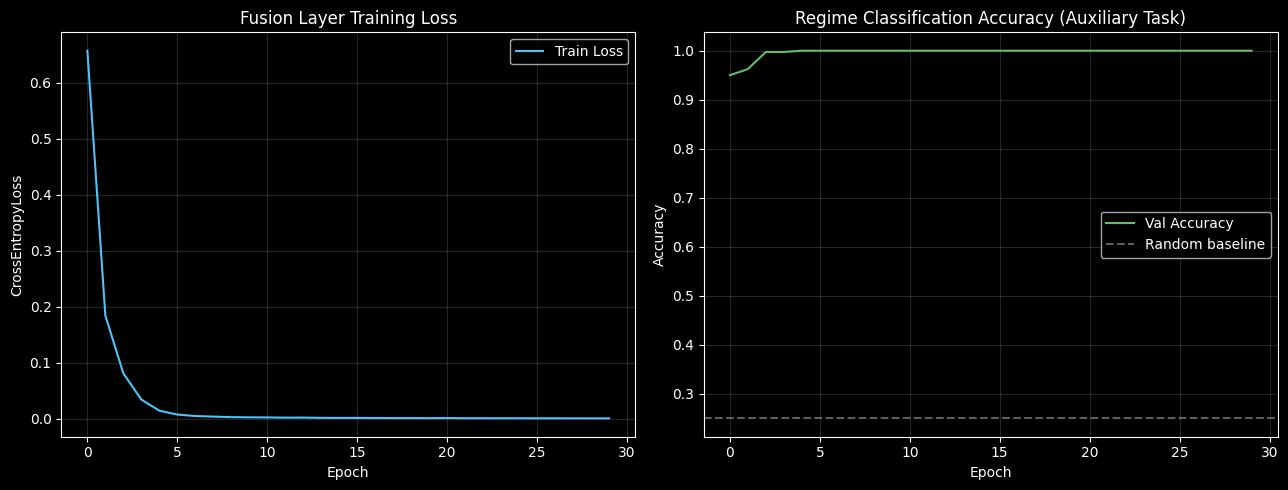

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(
    history["train_loss"],
    color=COLORS["primary"],
    linewidth=1.5,
    label="Train Loss",
)
axes[0].set_title("Fusion Layer Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("CrossEntropyLoss")
axes[0].legend()
axes[0].grid(alpha=0.15)

axes[1].plot(
    history["val_acc"],
    color=COLORS["success"],
    linewidth=1.5,
    label="Val Accuracy",
)
axes[1].axhline(
    0.25,
    color=COLORS["neutral"],
    linestyle="--",
    alpha=0.5,
    label="Random baseline",
)
axes[1].set_title("Regime Classification Accuracy (Auxiliary Task)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.15)

plt.tight_layout()
plt.savefig("08/08_fusion_training.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. t-SNE of Super-State — The Q2 Milestone Visualisation

Running t-SNE on 224d Super-State vectors...


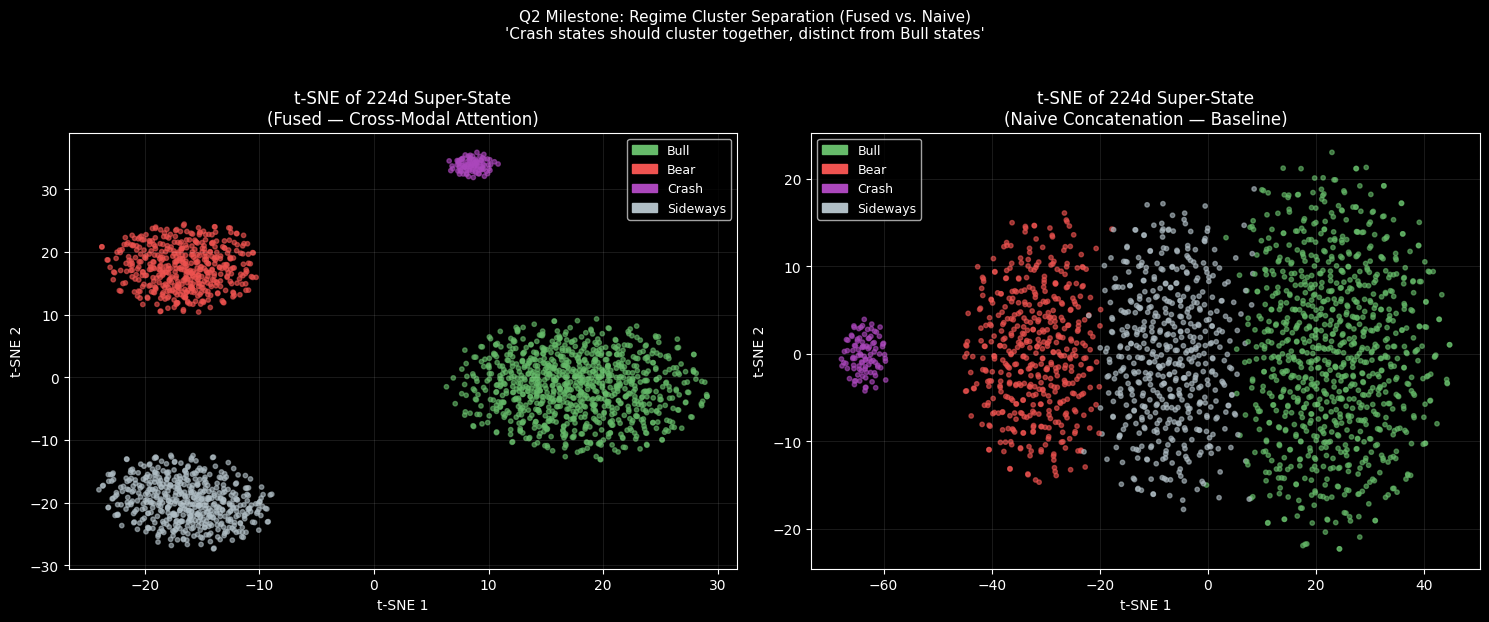


Silhouette Score (regime cluster separation):
  Fused Super-State : 0.7965
  Naive Concat      : 0.5034
  Fusion improvement: +0.2931
  Q2 Milestone      : ✅ PASS


In [10]:
# "Embedding Visualisation. Use t-SNE to visualise the 'Market States'.
#  We should see 'Crash' states clustering together visually, distinct
#  from 'Bull' states." (§9 Q2 Milestone)

fusion_model.eval()
all_super_states = []
all_regimes_out = []

full_loader = DataLoader(
    TensorDataset(X_temporal, X_semantic, X_structural, y_regimes),
    batch_size=256,
)
with torch.no_grad():
    for t_b, s_b, g_b, y_b in full_loader:
        t_b, s_b, g_b = t_b.to(DEVICE), s_b.to(DEVICE), g_b.to(DEVICE)
        out = fusion_model(t_b, s_b, g_b)
        all_super_states.append(out["super_state"].cpu().numpy())
        all_regimes_out.extend(y_b.numpy())

super_states_np = np.vstack(all_super_states)
regime_labels_np = np.array(all_regimes_out)

try:
    from sklearn.manifold import TSNE

    print("Running t-SNE on 224d Super-State vectors...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
    ss_2d = tsne.fit_transform(super_states_np[:2000])

    regime_color_map = {
        0: COLORS["success"],
        1: COLORS["danger"],
        2: COLORS["accent"],
        3: COLORS["neutral"],
    }
    point_colors = [regime_color_map[r] for r in regime_labels_np[:2000]]

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Super-State t-SNE
    axes[0].scatter(ss_2d[:, 0], ss_2d[:, 1], c=point_colors, alpha=0.6, s=10)
    legend_patches = [
        mpatches.Patch(color=c, label=r)
        for r, c in zip(
            ["Bull", "Bear", "Crash", "Sideways"], regime_color_map.values()
        )
    ]
    axes[0].legend(handles=legend_patches, fontsize=9)
    axes[0].set_title(
        "t-SNE of 224d Super-State\n(Fused — Cross-Modal Attention)"
    )
    axes[0].set_xlabel("t-SNE 1")
    axes[0].set_ylabel("t-SNE 2")
    axes[0].grid(alpha=0.10)

    # Naive concat t-SNE for comparison
    all_naive = np.concatenate(
        [emb_data["temporal"], emb_data["semantic"], emb_data["structural"]],
        axis=1,
    )
    naive_2d = TSNE(
        n_components=2, perplexity=30, random_state=42, max_iter=1000
    ).fit_transform(all_naive[:2000])

    axes[1].scatter(
        naive_2d[:, 0], naive_2d[:, 1], c=point_colors, alpha=0.6, s=10
    )
    axes[1].legend(handles=legend_patches, fontsize=9)
    axes[1].set_title(
        "t-SNE of 224d Super-State\n(Naive Concatenation — Baseline)"
    )
    axes[1].set_xlabel("t-SNE 1")
    axes[1].set_ylabel("t-SNE 2")
    axes[1].grid(alpha=0.10)

    plt.suptitle(
        "Q2 Milestone: Regime Cluster Separation (Fused vs. Naive)\n"
        "'Crash states should cluster together, distinct from Bull states'",
        fontsize=11,
        y=1.03,
    )
    plt.tight_layout()
    plt.savefig("08/08_super_state_tsne.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Check if Crash and Bull clusters are separated
    from sklearn.metrics import silhouette_score

    sil_fused = silhouette_score(ss_2d, regime_labels_np[:2000])
    sil_naive = silhouette_score(naive_2d, regime_labels_np[:2000])
    print("\nSilhouette Score (regime cluster separation):")
    print(f"  Fused Super-State : {sil_fused:.4f}")
    print(f"  Naive Concat      : {sil_naive:.4f}")
    print(f"  Fusion improvement: {sil_fused - sil_naive:+.4f}")
    print(
        f"  Q2 Milestone      : {'✅ PASS' if sil_fused > sil_naive else '❌ FAIL — debug fusion layer'}"
    )

except ImportError:
    print(
        "scikit-learn not installed — skipping t-SNE. pip install scikit-learn"
    )

## 9. Save Fusion Model for Notebook 09 (RL Agent Training)

In [ ]:
torch.save(fusion_model.state_dict(), "08/08_fusion_model.pt")
torch.save(super_states_np, "08/08_super_states.pt")

print("\nFusion model saved → 08_fusion_model.pt")
print(f"Super-State tensors → 08_super_states.pt  {super_states_np.shape}")
print("\nSummary — Fusion Layer:")
print(
    f"  Input  : {EMBEDDING_DIM_TEMPORAL}d (TFT) + {EMBEDDING_DIM_SEMANTIC}d (LLM) + {EMBEDDING_DIM_STRUCTURAL}d (GNN)"
)
print(f"  Output : {SUPER_STATE_DIM}d Super-State (via Cross-Modal Attention)")
print(f"  Params : {n_params_fusion:,}")


Fusion model saved    → 08_fusion_model.pt
Super-State tensors   → 08_super_states.pt  (2000, 224)

Summary — Fusion Layer:
  Input  : 128d (TFT) + 64d (LLM) + 32d (GNN)
  Output : 224d Super-State (via Cross-Modal Attention)
  Params : 1,020,576
